In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("P1 environment is working!")

P1 environment is working!


In [4]:
file_path = "../data/raw/CICIDS2017/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.shape

(529918, 79)

In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df.columns.tolist()

[' Destination Port',
 ' Flow Duration',
 ' Total Fwd Packets',
 ' Total Backward Packets',
 'Total Length of Fwd Packets',
 ' Total Length of Bwd Packets',
 ' Fwd Packet Length Max',
 ' Fwd Packet Length Min',
 ' Fwd Packet Length Mean',
 ' Fwd Packet Length Std',
 'Bwd Packet Length Max',
 ' Bwd Packet Length Min',
 ' Bwd Packet Length Mean',
 ' Bwd Packet Length Std',
 'Flow Bytes/s',
 ' Flow Packets/s',
 ' Flow IAT Mean',
 ' Flow IAT Std',
 ' Flow IAT Max',
 ' Flow IAT Min',
 'Fwd IAT Total',
 ' Fwd IAT Mean',
 ' Fwd IAT Std',
 ' Fwd IAT Max',
 ' Fwd IAT Min',
 'Bwd IAT Total',
 ' Bwd IAT Mean',
 ' Bwd IAT Std',
 ' Bwd IAT Max',
 ' Bwd IAT Min',
 'Fwd PSH Flags',
 ' Bwd PSH Flags',
 ' Fwd URG Flags',
 ' Bwd URG Flags',
 ' Fwd Header Length',
 ' Bwd Header Length',
 'Fwd Packets/s',
 ' Bwd Packets/s',
 ' Min Packet Length',
 ' Max Packet Length',
 ' Packet Length Mean',
 ' Packet Length Std',
 ' Packet Length Variance',
 'FIN Flag Count',
 ' SYN Flag Count',
 ' RST Flag Count',
 ' P

In [8]:
print("Number of columns:", len(df.columns))

Number of columns: 79


In [9]:
df.columns[-5:]

Index(['Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label'], dtype='str')

In [10]:
df["Label"].value_counts()

KeyError: 'Label'

In [11]:
print(df.columns.tolist()[-10:])

[' min_seg_size_forward', 'Active Mean', ' Active Std', ' Active Max', ' Active Min', 'Idle Mean', ' Idle Std', ' Idle Max', ' Idle Min', ' Label']


In [12]:
for col in df.columns[-10:]:
    print(repr(col))

' min_seg_size_forward'
'Active Mean'
' Active Std'
' Active Max'
' Active Min'
'Idle Mean'
' Idle Std'
' Idle Max'
' Idle Min'
' Label'


In [13]:
df.columns = df.columns.str.strip()

In [14]:
print(repr(df.columns[-1]))

'Label'


In [15]:
df["Label"].value_counts()

Label
BENIGN    529918
Name: count, dtype: int64

In [16]:
df["Label"].value_counts(normalize=True) * 100

Label
BENIGN    100.0
Name: proportion, dtype: float64

In [17]:
df["Label"].unique()

<StringArray>
['BENIGN']
Length: 1, dtype: str

In [18]:
import glob
import os

folder_path = "../data/raw/CICIDS2017/MachineLearningCVE"

csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(os.path.basename(file))

Number of CSV files: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [19]:
dataframes = []

for file in csv_files:
    print("Loading:", os.path.basename(file))
    
    temp_df = pd.read_csv(file)
    temp_df.columns = temp_df.columns.str.strip()
    
    dataframes.append(temp_df)

df_all = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", df_all.shape)

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined dataset shape: (2830743, 79)


In [20]:
df_all["Label"].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [21]:
df_all["Label"].value_counts(normalize=True) * 100

Label
BENIGN                        80.300366
DoS Hulk                       8.162981
PortScan                       5.614427
DDoS                           4.522735
DoS GoldenEye                  0.363615
FTP-Patator                    0.280421
SSH-Patator                    0.208320
DoS slowloris                  0.204752
DoS Slowhttptest               0.194260
Bot                            0.069452
Web Attack � Brute Force       0.053237
Web Attack � XSS               0.023033
Infiltration                   0.001272
Web Attack � Sql Injection     0.000742
Heartbleed                     0.000389
Name: proportion, dtype: float64

In [22]:
df_all["Label"].unique()

<StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack � Brute Force',
           'Web Attack � XSS', 'Web Attack � Sql Injection',
                'FTP-Patator',                'SSH-Patator',
              'DoS slowloris',           'DoS Slowhttptest',
                   'DoS Hulk',              'DoS GoldenEye',
                 'Heartbleed']
Length: 15, dtype: str

In [23]:
label_counts = df_all["Label"].value_counts()

class_summary = pd.DataFrame({
    "Attack_Type": label_counts.index,
    "Count": label_counts.values,
    "Percentage": (label_counts.values / len(df_all) * 100).round(4)
})

class_summary

,Attack_Type,Count,Percentage
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


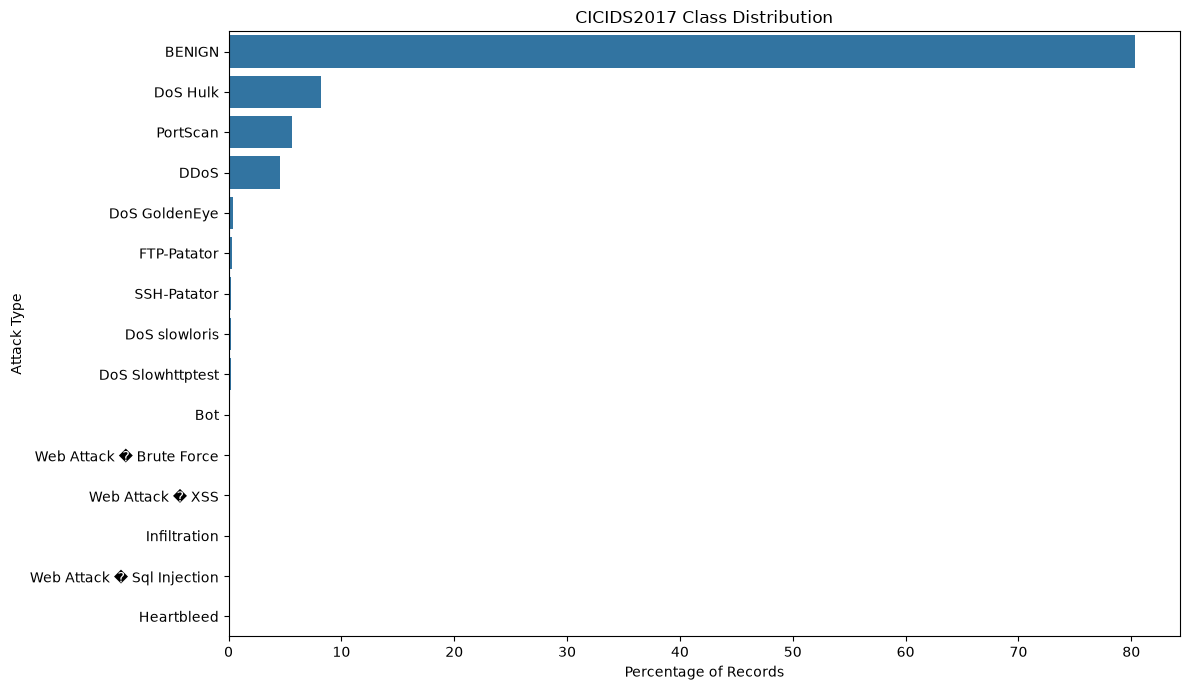

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=class_summary,
    x="Percentage",
    y="Attack_Type"
)

plt.title("CICIDS2017 Class Distribution")
plt.xlabel("Percentage of Records")
plt.ylabel("Attack Type")
plt.tight_layout()
plt.show()

In [25]:
print("Rows:", df_all.shape[0])
print("Columns:", df_all.shape[1])

Rows: 2830743
Columns: 79


In [26]:
print("Memory usage:", df_all.memory_usage(deep=True).sum() / (1024**2), "MB")

Memory usage: 1833.9173212051392 MB


In [27]:
df_all.dtypes.value_counts()

int64      54
float64    24
str         1
Name: count, dtype: int64

In [28]:
print("Numerical columns:", len(df_all.select_dtypes(include=np.number).columns))
print("Non-numerical columns:", len(df_all.select_dtypes(exclude=np.number).columns))

Numerical columns: 78
Non-numerical columns: 1


In [29]:
missing = df_all.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

Flow Bytes/s    1358
dtype: int64

In [30]:
numeric_df = df_all.select_dtypes(include=np.number)

infinite_counts = np.isinf(numeric_df).sum()

infinite_counts = infinite_counts[infinite_counts > 0].sort_values(ascending=False)

infinite_counts

Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

In [31]:
feature_columns = [
    col for col in df_all.columns
    if col != "Label"
]

print("Number of ML features:", len(feature_columns))

for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:2}. {feature}")

Number of ML features: 78
 1. Destination Port
 2. Flow Duration
 3. Total Fwd Packets
 4. Total Backward Packets
 5. Total Length of Fwd Packets
 6. Total Length of Bwd Packets
 7. Fwd Packet Length Max
 8. Fwd Packet Length Min
 9. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. SYN Flag Count
46. RST Flag Count
47. PSH Flag Cou

In [32]:
print("===== CICIDS2017 SUMMARY =====")

print("Dataset shape:", df_all.shape)
print("Number of features:", len(df_all.columns) - 1)
print("Number of classes:", df_all["Label"].nunique())

print("\n===== CLASS DISTRIBUTION =====")
print(class_summary)

print("\n===== DATA TYPES =====")
print(df_all.dtypes.value_counts())

print("\n===== MISSING VALUES =====")
print("Total missing values:", df_all.isnull().sum().sum())

print("\n===== DUPLICATES =====")
print("Duplicate rows:", df_all.duplicated().sum())

===== CICIDS2017 SUMMARY =====
Dataset shape: (2830743, 79)
Number of features: 78
Number of classes: 15

===== CLASS DISTRIBUTION =====
                   Attack_Type    Count  Percentage
0                       BENIGN  2273097     80.3004
1                     DoS Hulk   231073      8.1630
2                     PortScan   158930      5.6144
3                         DDoS   128027      4.5227
4                DoS GoldenEye    10293      0.3636
5                  FTP-Patator     7938      0.2804
6                  SSH-Patator     5897      0.2083
7                DoS slowloris     5796      0.2048
8             DoS Slowhttptest     5499      0.1943
9                          Bot     1966      0.0695
10    Web Attack � Brute Force     1507      0.0532
11            Web Attack � XSS      652      0.0230
12                Infiltration       36      0.0013
13  Web Attack � Sql Injection       21      0.0007
14                  Heartbleed       11      0.0004

===== DATA TYPES =====
int64  

In [33]:
class_summary.to_csv(
    "../data/processed/cicids2017_class_distribution.csv",
    index=False
)

In [35]:
df_all.shape

(2830743, 79)

In [36]:
label_counts = df_all["Label"].value_counts()

class_summary = pd.DataFrame({
    "Attack_Type": label_counts.index,
    "Count": label_counts.values,
    "Percentage": (label_counts.values / len(df_all) * 100).round(4)
})

class_summary

,Attack_Type,Count,Percentage
0,BENIGN,2273097,80.3004
1,DoS Hulk,231073,8.1630
2,PortScan,158930,5.6144
3,DDoS,128027,4.5227
4,DoS GoldenEye,10293,0.3636
5,FTP-Patator,7938,0.2804
6,SSH-Patator,5897,0.2083
7,DoS slowloris,5796,0.2048
8,DoS Slowhttptest,5499,0.1943
9,Bot,1966,0.0695


In [37]:
np.isinf(numeric_df).sum().sum()

np.int64(4376)

In [38]:
print("Positive infinity:", np.isposinf(numeric_df).sum().sum())
print("Negative infinity:", np.isneginf(numeric_df).sum().sum())

Positive infinity: 4376
Negative infinity: 0


In [39]:
duplicate_count = df_all.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 308381


In [40]:
numeric_columns = df_all.select_dtypes(include=np.number).columns
non_numeric_columns = df_all.select_dtypes(exclude=np.number).columns

print("Numerical columns:", len(numeric_columns))
print("Non-numerical columns:", len(non_numeric_columns))

Numerical columns: 78
Non-numerical columns: 1
